In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re

In [7]:
df.head()

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,...,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,56009081.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,24500000.0,...,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.012018e+11,2.022126e+10,pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,56247925.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,5145000.0,...,False,NaN,492.0,Abrag Real Estate,snawara71@gmail.com,2.010012e+11,2.010072e+11,2.022126e+10,ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,56253883.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,10800000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007
3,PPH0852SAB266X6GSVATJP4F0M,56250852.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,lowest price 2bds fullyfurnished @ lake view,10500000.0,...,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.010701e+11,2.022126e+10,ebrahim.hossam@spade-consultancy.com,2026-03-04T14:20:33.281007
4,QCSA4TNDEBBV7BNY8ANST3TB50,55995764.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Residential for Sale,completed,Exclusive Type M with Lowest Price RTM in PNC,19500000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007


In [8]:
df.shape

(39713, 53)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39713 entries, 0 to 39712
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           39712 non-null  str    
 1   internal_id          39712 non-null  float64
 2   category             39713 non-null  str    
 3   listing_type         39713 non-null  str    
 4   detail_url           39712 non-null  str    
 5   property_type        39712 non-null  str    
 6   offering_type        39712 non-null  str    
 7   completion_status    19763 non-null  str    
 8   title                39712 non-null  str    
 9   price_egp            39712 non-null  float64
 10  price_period         39712 non-null  str    
 11  price_currency       39713 non-null  str    
 12  location_full        39712 non-null  str    
 13  city                 39712 non-null  str    
 14  town                 39712 non-null  str    
 15  district             39366 non-null  str    
 1

In [10]:
dtype_table = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values
})

dtype_table

,Column,Dtype
0,listing_id,str
1,internal_id,float64
2,category,str
3,listing_type,str
4,detail_url,str
5,property_type,str
6,offering_type,str
7,completion_status,str
8,title,str
9,price_egp,float64


In [11]:
# =========================
# IDs → String
# =========================

id_cols = [
    "listing_id",
    "internal_id",
    "agent_id",
    "broker_id",
    "reference",
    "rera"
]

for col in id_cols:
    df[col] = df[col].astype("string")


# =========================
# Numeric columns
# =========================

numeric_cols = [
    "price_egp",
    "lat",
    "lon",
    "area_value",
    "images_count"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# =========================
# Bedrooms & Bathrooms
# =========================

df["bedrooms"] = pd.to_numeric(
    df["bedrooms"],
    errors="coerce"
).astype("Int64")

df["bathrooms"] = pd.to_numeric(
    df["bathrooms"],
    errors="coerce"
).astype("Int64")


# =========================
# Phone numbers → String
# =========================

phone_cols = [
    "broker_phone",
    "contact_phone",
    "contact_whatsapp"
]

for col in phone_cols:
    df[col] = df[col].astype("string")


# =========================
# Date columns
# =========================

df["listed_date"] = pd.to_datetime(
    df["listed_date"],
    errors="coerce",
    utc=True
)

df["scraped_at"] = pd.to_datetime(
    df["scraped_at"],
    errors="coerce",
    utc=True
)


# =========================
# Boolean columns
# =========================

bool_cols = [
    "is_premium",
    "is_verified",
    "is_featured",
    "is_new_construction",
    "is_direct_from_dev",
    "is_exclusive",
    "has_view_360",
    "agent_is_super"
]

for col in bool_cols:
    df[col] = df[col].astype("boolean")


# =========================
# Categorical columns
# =========================

categorical_cols = [
    "category",
    "listing_type",
    "property_type",
    "offering_type",
    "completion_status",
    "price_period",
    "price_currency",
    "city",
    "town",
    "district",
    "subdistrict",
    "area_unit",
    "furnished",
    "listing_level",
    "payment_method"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")


# =========================
# Text columns
# =========================

text_cols = [
    "detail_url",
    "title",
    "location_full",
    "video_url",
    "description",
    "amenities",
    "agent_name",
    "agent_email",
    "agent_languages",
    "broker_name",
    "broker_email",
    "broker_phone",
    "contact_email"
]

for col in text_cols:
    df[col] = df[col].astype("string")

In [12]:
df.describe()

,price_egp,lat,lon,bedrooms,bathrooms,area_value,images_count
count,3.971200e+04,39712.000000,39712.000000,38369.0,39415.0,39712.000000,39713.000000
mean,7.988803e+06,29.976419,31.318191,3.01681,2.872993,218.483229,12.275678
std,2.449279e+07,0.602531,0.857351,1.023165,1.206432,781.823867,4.823324
min,1.300000e+03,25.069366,25.476135,1.0,1.0,1.000000,0.000000
25%,6.500000e+04,30.001993,31.015570,2.0,2.0,130.000000,10.000000
50%,6.000000e+05,30.025003,31.497156,3.0,3.0,175.000000,11.000000
75%,9.113125e+06,30.061470,31.546247,3.0,3.0,245.000000,14.000000
max,1.000000e+09,31.497467,34.896572,7.0,7.0,96600.000000,30.000000


In [13]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = (
    missing_values
    .query("missing_count > 0")
    .sort_values(by="missing_percentage", ascending=False)
    .reset_index()
)

missing_values = missing_values.rename(columns={"index": "Feature"})

missing_values

,Feature,missing_count,missing_percentage
0,rera,39713,100.000000
1,video_url,39511,99.491350
2,agent_languages,30541,76.904288
3,completion_status,19950,50.235439
4,payment_method,19774,49.792259
5,furnished,8385,21.113993
6,subdistrict,6759,17.019616
7,bedrooms,1344,3.384282
8,district,347,0.873769
9,bathrooms,298,0.750384


In [14]:
if not missing_values.empty:
    fig = px.bar(missing_values, x='missing_percentage', y='Feature', orientation='h',
                 title="Percentage of Missing Values per Feature",
                 color='missing_percentage', color_continuous_scale='Reds',
                 text=missing_values['missing_percentage'].apply(lambda x: f'{x:.1f}%'))
    fig.update_layout(height=600, showlegend=False)

    fig.show()
else:
    print("Wow! No missing values tracked by straightforward NaN.")

# completion status

In [15]:
df["completion_status"].value_counts(dropna=False)

completion_status
NaN                  19950
completed            10135
completed_primary     4304
off_plan_primary      4138
off_plan              1186
Name: count, dtype: int64

In [16]:
df["completion_status"] = (
    df["completion_status"]
    .cat.add_categories("Not Specified")
    .fillna("Not Specified")
)

In [17]:
df["completion_status"].value_counts(dropna=False)

completion_status
Not Specified        19950
completed            10135
completed_primary     4304
off_plan_primary      4138
off_plan              1186
Name: count, dtype: int64

# payment_method

In [18]:
df["payment_method"].value_counts(dropna=False)

payment_method
NaN                    19774
cash                   12806
cash | installments     3758
installments            3375
Name: count, dtype: int64

In [19]:
df["payment_method"] = (
    df["payment_method"]
    .cat.add_categories("Not Specified")
    .fillna("Not Specified")
)

In [20]:
df["payment_method"].value_counts(dropna=False)

payment_method
Not Specified          19774
cash                   12806
cash | installments     3758
installments            3375
Name: count, dtype: int64

In [21]:
df["payment_method"] = (
    df["payment_method"]
    .str.strip()
    .str.title()
)

In [22]:
df["payment_method"].value_counts(dropna=False)

payment_method
Not Specified          19774
Cash                   12806
Cash | Installments     3758
Installments            3375
Name: count, dtype: int64

# furnished


In [23]:
df["furnished"].value_counts(dropna=False)

furnished
YES       12719
NO        11033
NaN        8385
PARTLY     7576
Name: count, dtype: int64

In [24]:
furnished_mapping = {
    "YES": "Furnished",
    "NO": "Unfurnished",
    "PARTLY": "Partially Furnished"
}

df["furnished"] = df["furnished"].map(furnished_mapping)
df["furnished"].value_counts(dropna=False)

furnished
Furnished              12719
Unfurnished            11033
NaN                     8385
Partially Furnished     7576
Name: count, dtype: int64

In [25]:
df["furnished"] = (
    df["furnished"]
    .cat.add_categories("Not Specified")
    .fillna("Not Specified")
)

In [26]:
df[f"furnished"].value_counts(dropna=False)

furnished
Furnished              12719
Unfurnished            11033
Not Specified           8385
Partially Furnished     7576
Name: count, dtype: int64

# subdistrict

In [27]:
df["subdistrict"] = (
    df["subdistrict"]
    .cat.add_categories("Not Specified")
    .fillna("Not Specified")
)

df["subdistrict"].value_counts(dropna=False)

subdistrict
5th Settlement Compounds    11671
Not Specified                6759
El Katameya Compounds         969
Cairo Festival City           859
El Rehab Extension            624
                            ...  
Zayard Elite                    1
Zayard North Strike             1
Zayed Greens Compound           1
lakefront                       1
بوابة النعيم                    1
Name: count, Length: 1135, dtype: int64

# district

In [28]:
df["district"]

0                  The 5th Settlement
1              Sheikh Zayed Compounds
2                  The 5th Settlement
3                  The 5th Settlement
4                  The 5th Settlement
                     ...             
39708                        Al Rehab
39709    Cairo Alexandria Desert Road
39710    Cairo Alexandria Desert Road
39711    Cairo Alexandria Desert Road
39712              The 5th Settlement
Name: district, Length: 39713, dtype: category
Categories (519, str): ['10th District', '10th Zone', '11th District', '12th District', ..., 'Zaki Ali St.', 'Zezenia', 'Zezenia 10th of Ramadan', 'katameya coast']

In [29]:
df.loc[
    df["district"].isna(),
    ["location_full", "city", "town", "district", "subdistrict"]
].head(20)

,location_full,city,town,district,subdistrict
5,<NA>,NaN,NaN,NaN,Not Specified
1215,"Noor City, Cairo",Cairo,Noor City,NaN,Not Specified
1618,"Noor City, Cairo",Cairo,Noor City,NaN,Not Specified
1879,"Mohandessin, Giza",Giza,Mohandessin,NaN,Not Specified
1959,"Noor City, Cairo",Cairo,Noor City,NaN,Not Specified
2400,"Noor City, Cairo",Cairo,Noor City,NaN,Not Specified
2402,"Noor City, Cairo",Cairo,Noor City,NaN,Not Specified
2564,"Noor City, Cairo",Cairo,Noor City,NaN,Not Specified
2610,"Noor City, Cairo",Cairo,Noor City,NaN,Not Specified
2661,"Sheikh Zayed City, Giza",Giza,Sheikh Zayed City,NaN,Not Specified


In [30]:
df.loc[
    df["district"].notna(),
    ["location_full", "city", "town", "district", "subdistrict"]
].head(20)

,location_full,city,town,district,subdistrict
0,"The Lakeview Boutique Villas, 5th Settlement C...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds
1,"Village West, Sheikh Zayed Compounds, Sheikh Z...",Giza,Sheikh Zayed City,Sheikh Zayed Compounds,Village West
2,"Palm Hills New Cairo, 5th Settlement Compounds...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds
3,"Lake View Residence, 5th Settlement Compounds,...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds
4,"Palm Hills New Cairo, 5th Settlement Compounds...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds
6,"The Address, 12th District, Sheikh Zayed City,...",Giza,Sheikh Zayed City,12th District,The Address
7,"Amwaj, Sidi Abdel Rahman, North Coast",North Coast,Sidi Abdel Rahman,Amwaj,Not Specified
8,"Aeon, 6 October Compounds, 6 October City, Giza",Giza,6 October City,6 October Compounds,Aeon
9,"Swan Lake Gouna, El Gouna, Hurghada, Red Sea",Red Sea,Hurghada,El Gouna,Swan Lake Gouna
10,"Palm Hills New Cairo, 5th Settlement Compounds...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds


In [31]:
district_nulls = df[df["district"].isna()]
district_nulls[
    ["location_full", "city", "town", "subdistrict"]
].notna().sum()

location_full    346
city             346
town             346
subdistrict      347
dtype: int64

In [32]:
district_nulls[
    ["location_full", "city", "town", "subdistrict"]
].head(20)

,location_full,city,town,subdistrict
5,<NA>,NaN,NaN,Not Specified
1215,"Noor City, Cairo",Cairo,Noor City,Not Specified
1618,"Noor City, Cairo",Cairo,Noor City,Not Specified
1879,"Mohandessin, Giza",Giza,Mohandessin,Not Specified
1959,"Noor City, Cairo",Cairo,Noor City,Not Specified
2400,"Noor City, Cairo",Cairo,Noor City,Not Specified
2402,"Noor City, Cairo",Cairo,Noor City,Not Specified
2564,"Noor City, Cairo",Cairo,Noor City,Not Specified
2610,"Noor City, Cairo",Cairo,Noor City,Not Specified
2661,"Sheikh Zayed City, Giza",Giza,Sheikh Zayed City,Not Specified


In [33]:
subdistrict_district = (
    df.dropna(subset=["district"])
      .groupby("subdistrict")["district"]
      .nunique()
      .sort_values(ascending=False)
)

subdistrict_district.head(20)

subdistrict
Not Specified                         419
1st Neighborhood                        9
Al Geish Road                           7
Port Said St.                           5
2nd Neighborhood                        4
Al Nozha St.                            3
4th Neighborhood                        3
Al Nasr Road                            3
Mostafa Kamel St.                       3
Street 13                               3
Africa   Emtedad Moustafa Al Nahas      2
Al Orouba St.                           2
El Mariouteya                           2
Ahmed Al Zomor St.                      2
3rd Neighborhood                        2
Beta Greens                             2
De Joya                                 2
Al Shabab St.                           2
Abdel Salam Aref St.                    2
Italian Square                          2
Name: district, dtype: int64

In [34]:
df["district"] = (
    df["district"]
    .cat.add_categories("Not Specified")
    .fillna("Not Specified")
)

df["district"].value_counts(dropna=False)

district
The 5th Settlement        13082
Sheikh Zayed Compounds     3744
6 October Compounds        1485
North Investors Area       1180
Privado                    1007
                          ...  
Victoria                      1
Villagio                      1
White Nile St.                1
Zahraa Masr El Kadima         1
Zaki Ali St.                  1
Name: count, Length: 520, dtype: int64

In [35]:
df["amenities"].value_counts(dropna=False)

amenities
Balcony | Built in Wardrobes | Central A/C | Covered Parking | Kitchen Appliances | Maids Room | Private Garden | Private Pool | Shared Pool | Study | View of Water | Security | Shared Spa | Shared Gym | Walk-in Closet | View of Landmark | Lobby in Building | Children's Pool    1467
Balcony | Security                                                                                                                                                                                                                                                                     1182
Balcony                                                                                                                                                                                                                                                                                1155
Balcony | Security | Lobby in Building                                                                                                    

# agent_name	

In [36]:
agent_nulls=df[df["agent_name"].isna()][
    ["agent_id", "agent_name", "agent_email"]
]
agent_nulls

,agent_id,agent_name,agent_email
5,<NA>,<NA>,<NA>
12381,40973.0,<NA>,m.rashead@ymail.com
12391,40973.0,<NA>,m.rashead@ymail.com
12401,40973.0,<NA>,m.rashead@ymail.com
23113,40373.0,<NA>,circle.egypt.realestate@gmail.com
32302,40373.0,<NA>,circle.egypt.realestate@gmail.com
35177,42621.0,<NA>,sarashalaby237@gmail.com
36387,40373.0,<NA>,circle.egypt.realestate@gmail.com


In [37]:
emails = agent_nulls["agent_email"].dropna().unique()

df[df["agent_email"].isin(emails)][
    ["agent_id", "agent_name", "agent_email"]
].sort_values("agent_email")

,agent_id,agent_name,agent_email
23113,40373.0,<NA>,circle.egypt.realestate@gmail.com
32302,40373.0,<NA>,circle.egypt.realestate@gmail.com
36387,40373.0,<NA>,circle.egypt.realestate@gmail.com
12381,40973.0,<NA>,m.rashead@ymail.com
12391,40973.0,<NA>,m.rashead@ymail.com
12401,40973.0,<NA>,m.rashead@ymail.com
35177,42621.0,<NA>,sarashalaby237@gmail.com


In [38]:
def extract_agent_name(row):
    if pd.notna(row["agent_name"]):
        return row["agent_name"]

    if pd.notna(row["agent_email"]):
        username = row["agent_email"].split("@")[0]

        # remove numbers
        username = re.sub(r"\d+", "", username)

        # replace separators with spaces
        username = re.sub(r"[._-]+", " ", username)

        # clean extra spaces
        username = " ".join(username.split())

        return username.title()

    return "Not Specified"


df["agent_name"] = df.apply(extract_agent_name, axis=1)

In [39]:
emails = agent_nulls["agent_email"].dropna().unique()

df[df["agent_email"].isin(emails)][
    ["agent_id", "agent_name", "agent_email"]
].sort_values("agent_email")

,agent_id,agent_name,agent_email
23113,40373.0,Circle Egypt Realestate,circle.egypt.realestate@gmail.com
32302,40373.0,Circle Egypt Realestate,circle.egypt.realestate@gmail.com
36387,40373.0,Circle Egypt Realestate,circle.egypt.realestate@gmail.com
12381,40973.0,M Rashead,m.rashead@ymail.com
12391,40973.0,M Rashead,m.rashead@ymail.com
12401,40973.0,M Rashead,m.rashead@ymail.com
35177,42621.0,Sarashalaby,sarashalaby237@gmail.com


In [40]:
df[["agent_name", "agent_email"]].dropna().drop_duplicates(subset="agent_name").head(20)

,agent_name,agent_email
0,pierre osama,pierre.Osama@spade-consultancy.com
1,Rana Bahaa ElDeen,ranoushamer901@gmail.com
2,Ashraf Shaaban,ashrafsobhy99@hotmail.com
3,ebrahim hossam,ebrahim.hossam@spade-consultancy.com
6,Reham Hossam,rehamhos123@gmail.com
7,Mona Ashraf,mona.imageinv@gmail.com
8,sahar negm,saharnegm756@gmail.com
9,Sarah Fahmy,sfahmy@hap.com.eg
10,Dalia Hazem,daliahazem999@gmail.com
11,Aya Adel,aya.adel@spade-consultancy.com


# broker_phone

In [41]:
df["broker_phone"] = df["broker_phone"].fillna("Not Available")

# bedrooms


In [42]:
df["bedrooms"] = df["bedrooms"].fillna(
    df["bedrooms"].median()
)

# bathrooms

In [43]:
df["bathrooms"] = df["bathrooms"].fillna(
    df["bathrooms"].median()
)

 # amenities

In [44]:
df["amenities"] = df["amenities"].fillna("Not Available")

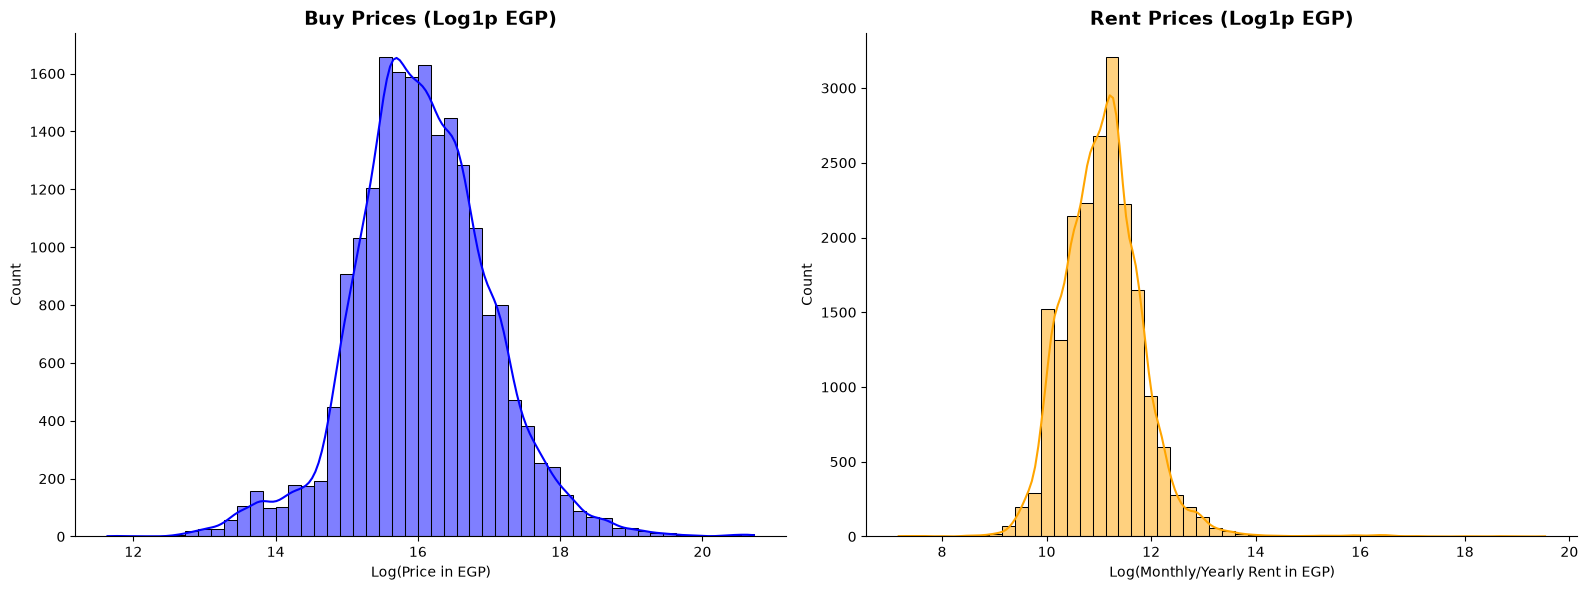

In [45]:
df_buy = df[df['category'] == 'buy'].copy()
df_rent = df[df['category'] == 'rent'].copy()

# Filter out extreme anomalies for clean plots (e.g., price <= 0)
df_buy = df_buy[df_buy['price_egp'] > 1000]
df_rent = df_rent[df_rent['price_egp'] > 100]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(np.log1p(df_buy['price_egp']), ax=axes[0], color='blue', bins=50, kde=True)
axes[0].set_title('Buy Prices (Log1p EGP)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log(Price in EGP)')

sns.histplot(np.log1p(df_rent['price_egp']), ax=axes[1], color='orange', bins=50, kde=True)
axes[1].set_title('Rent Prices (Log1p EGP)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Monthly/Yearly Rent in EGP)')

sns.despine()
plt.tight_layout()
plt.show()

In [46]:
# =========================
# Select Columns
# =========================

selected_cols = [
    # Listing
    "listing_id",
    "property_type",
    "offering_type",
    "completion_status",
    "price_egp",
    "price_period",
    "area_value",
    "bedrooms",
    "bathrooms",
    "furnished",

    # Location
    "city",
    "town",
    "district",
    "subdistrict",
    "lat",
    "lon",

    # Features
    "is_premium",
    "is_verified",
    "is_featured",
    "is_new_construction",
    "is_direct_from_dev",
    "is_exclusive",
    "has_view_360",
    "images_count",

    # Agent / Broker
    "agent_id",
    "agent_name",
    "agent_is_super",
    "broker_id",
    "broker_name",

    # Dates
    "listed_date",
    "scraped_at"
]

df = df[selected_cols].copy()

In [47]:
df = df.dropna(subset=["listing_id"])

In [48]:
df.to_csv("Egypt Real Estate Cleaning Data.csv",index=False,encoding="utf-8-sig")

In [49]:
df.head(6)

,listing_id,property_type,offering_type,completion_status,price_egp,price_period,area_value,bedrooms,bathrooms,furnished,...,is_exclusive,has_view_360,images_count,agent_id,agent_name,agent_is_super,broker_id,broker_name,listed_date,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,Duplex,Residential for Sale,completed,24500000.0,sell,445.0,3,6,Not Specified,...,False,False,6,58866.0,pierre osama,False,5758.0,Spade consultancy,2026-03-03 19:15:06+00:00,2026-03-04 14:20:33.281007+00:00
1,K1JC3D6N57ED52N3VX1QQKHHXG,Apartment,Residential for Sale,off_plan,5145000.0,sell,123.0,2,2,Partially Furnished,...,False,False,10,67166.0,Rana Bahaa ElDeen,False,492.0,Abrag Real Estate,2026-03-04 11:24:23+00:00,2026-03-04 14:20:33.281007+00:00
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,Apartment,Residential for Sale,completed,10800000.0,sell,250.0,4,4,Not Specified,...,False,False,13,47158.0,Ashraf Shaaban,False,5279.0,Premises,2026-03-04 14:03:51+00:00,2026-03-04 14:20:33.281007+00:00
3,PPH0852SAB266X6GSVATJP4F0M,Apartment,Residential for Sale,completed,10500000.0,sell,136.0,2,2,Furnished,...,False,False,11,63401.0,ebrahim hossam,False,5758.0,Spade consultancy,2026-03-04 12:38:11+00:00,2026-03-04 14:20:33.281007+00:00
4,QCSA4TNDEBBV7BNY8ANST3TB50,Villa,Residential for Sale,completed,19500000.0,sell,255.0,4,4,Not Specified,...,False,False,17,47158.0,Ashraf Shaaban,False,5279.0,Premises,2026-03-03 09:45:41+00:00,2026-03-04 14:20:33.281007+00:00
6,8QH1VD951AYY4QFV05F0VND6BM,Apartment,Residential for Sale,completed,11750000.0,sell,209.0,4,2,Unfurnished,...,False,False,24,66482.0,Reham Hossam,False,492.0,Abrag Real Estate,2026-03-04 13:57:39+00:00,2026-03-04 14:20:33.281007+00:00


In [50]:
df.isnull().sum().sort_values(ascending=False)

listing_id             0
property_type          0
offering_type          0
completion_status      0
price_egp              0
price_period           0
area_value             0
bedrooms               0
bathrooms              0
furnished              0
city                   0
town                   0
district               0
subdistrict            0
lat                    0
lon                    0
is_premium             0
is_verified            0
is_featured            0
is_new_construction    0
is_direct_from_dev     0
is_exclusive           0
has_view_360           0
images_count           0
agent_id               0
agent_name             0
agent_is_super         0
broker_id              0
broker_name            0
listed_date            0
scraped_at             0
dtype: int64